# Bone marrow integration with regularizedvi (GammaPoisson, early stopping)

This notebook uses `AmbientRegularizedSCVI` with the default GammaPoisson likelihood and the same architecture as the main tutorial, but with early stopping and checkpoint saving every 200 epochs.

Training uses `train_size=0.9` (90/10 train/val split), `early_stopping_patience=20`, and `max_epochs=4000` as upper bound.

Compare with:
- [bone_marrow_gamma_poisson.ipynb](bone_marrow_gamma_poisson.ipynb) — same model trained for 2000 epochs (no early stopping)
- [bone_marrow_gamma_poisson_1375ep.ipynb](bone_marrow_gamma_poisson_1375ep.ipynb) — same model trained for 1375 epochs

In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
import scipy
import torch

import scvi
import regularizedvi

# Simple text progress bar (works with papermill)
scvi.settings.progress_bar_style = "tqdm"

# Use high-precision matmul for better numerical stability on GPU
torch.set_float32_matmul_precision("high")

rcParams["pdf.fonttype"] = 42  # enables correct plotting of text for publication figures

## 1. Load data

Load the bone marrow multiome dataset and extract the GEX (gene expression) modality.

In [ ]:
import os

from regularizedvi.utils import download_bone_marrow_dataset

results_folder = "results/regularizedvi_gamma_poisson_early_stopping/"
os.makedirs(results_folder, exist_ok=True)

h5ad_path = download_bone_marrow_dataset(data_folder="data/")
adata = sc.read_h5ad(h5ad_path)

# Extract gene expression only
adata = adata[:, adata.var["feature_types"] == "GEX"].copy()
adata.var["SYMBOL"] = adata.var_names.values.copy()
adata.var_names = adata.var["gene_ids"].values.astype(str).copy()
adata.X = adata.layers["counts"]

print(adata)
print(f"\nBatches: {adata.obs['batch'].nunique()}")
print(f"Sites: {adata.obs['site'].nunique()}")
print(f"Donors: {adata.obs['donor'].nunique()}")

## 2. Quality control

In [3]:
# Batch and cell type composition
for c in ["batch", "site", "donor", "l2_cell_type"]:
    print(adata.obs[c].value_counts())
    print()

batch
s4d8     9876
s4d1     8023
s3d10    6780
s1d2     6740
s1d1     6224
s2d4     6111
s2d5     4895
s3d3     4325
s4d9     4325
s1d3     4279
s2d1     4220
s3d7     1770
s3d6     1679
Name: count, dtype: int64



site
site4    22224
site1    17243
site2    15226
site3    14554
Name: count, dtype: int64

donor
donor1     18467
donor8      9876
donor3      8604
donor10     6780
donor2      6740
donor4      6111
donor5      4895
donor9      4325
donor7      1770
donor6      1679
Name: count, dtype: int64

l2_cell_type
CD8+ T activated    11589
CD14+ Mono          10842
NK                   6929
CD4+ T activated     5526
Naive CD20+ B        5052
Erythroblast         4916
CD4+ T naive         4398
Transitional B       2810
Proerythroblast      2300
CD16+ Mono           1894
B1 B                 1890
Normoblast           1780
Early Lymphoid       1779
G/M prog             1203
pDC                  1191
HSC                  1072
CD8+ T naive         1012
MK/E prog             884
cDC2                  859
ILC                   834
Plasma                379
Other Myeloid         108
Name: count, dtype: int64



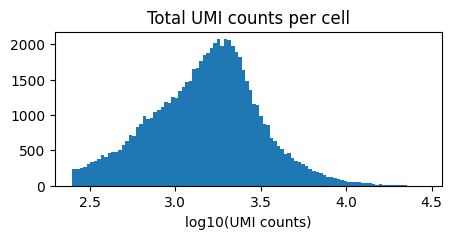

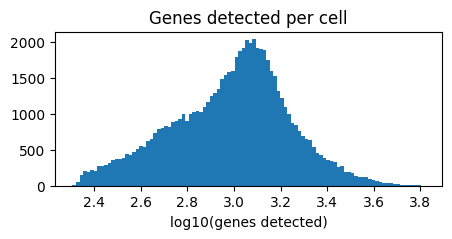

In [4]:
# QC distributions
rcParams["figure.figsize"] = 5, 2
plt.hist(np.log10(adata.obs["GEX_n_counts"]), bins=100)
plt.xlabel("log10(UMI counts)")
plt.title("Total UMI counts per cell")
plt.show()

plt.hist(np.log10(adata.obs["GEX_n_genes"]), bins=100)
plt.xlabel("log10(genes detected)")
plt.title("Genes detected per cell")
plt.show()

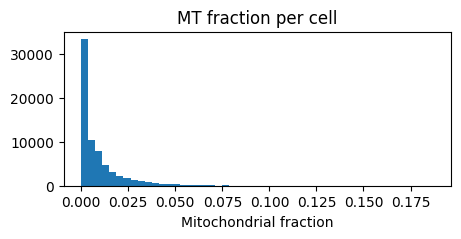

In [5]:
# Mitochondrial fraction
adata.var["mt"] = [gene.startswith("MT-") for gene in adata.var["SYMBOL"]]
adata.obs["mt_frac"] = adata[:, adata.var["mt"].tolist()].X.sum(1).A.squeeze() / adata.obs["GEX_n_counts"]

plt.hist(adata.obs["mt_frac"], bins=50)
plt.xlabel("Mitochondrial fraction")
plt.title("MT fraction per cell")
plt.show()

### Gene selection for QC

Select informative genes using `regularizedvi.utils.filter_genes` (adapted from cell2location). These genes are used for doublet detection below; the actual subsetting of `adata` happens after cell filtering.

/software/conda/users/vk7/regularizedvi/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/software/conda/users/vk7/regularizedvi/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


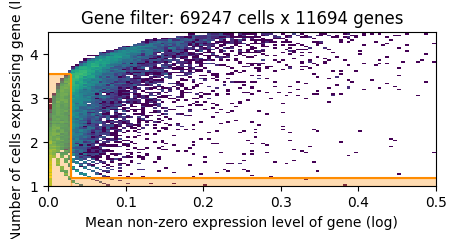

In [6]:
from regularizedvi.utils import filter_genes

selected = filter_genes(
    adata,
    cell_count_cutoff=15,
    cell_percentage_cutoff2=0.05,
    nonz_mean_cutoff=1.07,
)

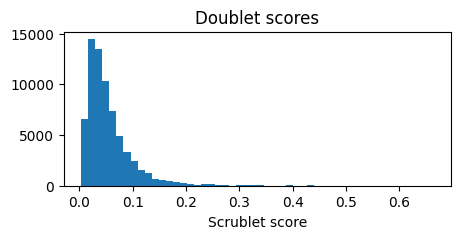

Fraction above 0.18 threshold: 0.025


In [7]:
adata_for_scrublet = adata[:, selected].copy()
sc.pp.scrublet(
    adata_for_scrublet,
    batch_key="batch",
    n_prin_comps=40,
    verbose=False,
)
adata.obs["doublet_score"] = adata_for_scrublet.obs["doublet_score"]
adata.obs["predicted_doublet"] = adata_for_scrublet.obs["predicted_doublet"]
del adata_for_scrublet

plt.hist(adata.obs["doublet_score"], bins=50)
plt.xlabel("Scrublet score")
plt.title("Doublet scores")
plt.show()

print(f"Fraction above 0.18 threshold: {(adata.obs['doublet_score'] > 0.18).mean():.3f}")

In [8]:
# Cell filtering
n_before = adata.n_obs
adata = adata[
    (adata.obs["GEX_n_genes"] > 500)
    & (adata.obs["GEX_n_counts"] > 1000)
    & (adata.obs["GEX_n_counts"] < 80000)
    & (adata.obs["GEX_n_genes"] < 10000)
    & (adata.obs["ATAC_atac_fragments"] > 1000)
    & (adata.obs["ATAC_atac_fragments"] < 100000)
    & (adata.obs["mt_frac"] < 0.20)
    & (adata.obs["doublet_score"] < 0.18),
    :,
]
print(f"Filtered {n_before} → {adata.n_obs} cells ({n_before - adata.n_obs} removed)")

Filtered 69247 → 46534 cells (22713 removed)


## 3. Gene filtering

Recompute gene selection on the filtered cells — cell composition affects detection rates, so we re-run `filter_genes` after QC filtering.

/software/conda/users/vk7/regularizedvi/lib/python3.11/site-packages/regularizedvi/utils/_filtering.py:30: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["n_cells"] = np.array((adata.X > 0).sum(0)).flatten()


/software/conda/users/vk7/regularizedvi/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/software/conda/users/vk7/regularizedvi/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


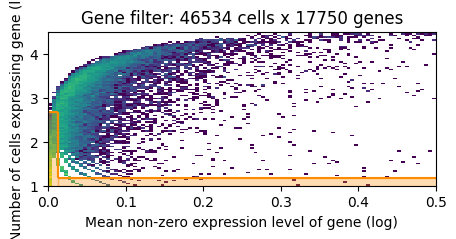

Selected 17750 genes


In [9]:
selected = filter_genes(
    adata,
    cell_count_cutoff=15,
    cell_percentage_cutoff2=0.01,
    nonz_mean_cutoff=1.03,
)
adata = adata[:, selected].copy()

print(f"Selected {adata.n_vars} genes")

## 4. Model setup and training

### Setup anndata

- `ambient_covariate_keys=['batch']` — identifies groups for per-gene additive ambient RNA background ($s_{e,g}$).
- `nn_conditioning_covariate_keys=['site', 'donor']` — known technical/biological covariates injected into encoder/decoder as multiplicative effects (like $p_{tg}$ in cell2location).
- `dispersion_key='batch'` — groups sharing per-gene overdispersion parameters ($\theta_{g,d}$).
- `library_size_key='batch'` — groups sharing library size prior ($\text{LogNormal}(\mu_p, 0.05\sigma_p)$).

In [ ]:
adata.layers["counts"] = adata.X

### Create model

Uses the default GammaPoisson likelihood with cell2location-style dispersion prior (Exp on $1/\sqrt{\theta}$, pushing $\theta$ large toward Poisson).

In [ ]:
# Papermill parameters
results_folder = "results/regularizedvi_gamma_poisson_early_stopping/"
additive_bg_prior_alpha = 1.0
additive_bg_prior_beta = 100.0
use_additive_background = 1
regularise_background = 1
compute_pearson = 1
use_feature_scaling = 1
library_log_means_centering_sensitivity = None
px_r_init_mean = None
px_r_init_std = None
additive_bg_init_mean = None
additive_bg_init_std = None
early_stopping_min_delta_per_feature = None
max_epochs = 4000
wandb_project = None
wandb_name = None
wandb_entity = None
wandb_notes = None
wandb_group = None

In [ ]:
from regularizedvi.utils import coerce_papermill_params, finish_wandb, log_figure_to_wandb, setup_wandb_logger

# Convert papermill params to correct types (papermill -r passes strings)
params = coerce_papermill_params(
    additive_bg_prior_alpha=(additive_bg_prior_alpha, float),
    additive_bg_prior_beta=(additive_bg_prior_beta, float),
    use_additive_background=(use_additive_background, bool),
    regularise_background=(regularise_background, bool),
    compute_pearson=(compute_pearson, bool),
    use_feature_scaling=(use_feature_scaling, bool),
    library_log_means_centering_sensitivity=(library_log_means_centering_sensitivity, "float_or_none"),
    px_r_init_mean=(px_r_init_mean, "float_or_none"),
    px_r_init_std=(px_r_init_std, "float_or_none"),
    additive_bg_init_mean=(additive_bg_init_mean, "float_or_none"),
    additive_bg_init_std=(additive_bg_init_std, "float_or_none"),
    early_stopping_min_delta_per_feature=(early_stopping_min_delta_per_feature, "float_or_none"),
    max_epochs=(max_epochs, int),
    wandb_project=(wandb_project, "str_or_none"),
    wandb_name=(wandb_name, "str_or_none"),
    wandb_entity=(wandb_entity, "str_or_none"),
    wandb_notes=(wandb_notes, "str_or_none"),
    wandb_group=(wandb_group, "str_or_none"),
)
additive_bg_prior_alpha = params["additive_bg_prior_alpha"]
additive_bg_prior_beta = params["additive_bg_prior_beta"]
use_additive_background = params["use_additive_background"]
regularise_background = params["regularise_background"]
compute_pearson = params["compute_pearson"]
use_feature_scaling = params["use_feature_scaling"]
library_log_means_centering_sensitivity = params["library_log_means_centering_sensitivity"]
px_r_init_mean = params["px_r_init_mean"]
px_r_init_std = params["px_r_init_std"]
additive_bg_init_mean = params["additive_bg_init_mean"]
additive_bg_init_std = params["additive_bg_init_std"]
early_stopping_min_delta_per_feature = params["early_stopping_min_delta_per_feature"]
max_epochs = params["max_epochs"]
wandb_project = params["wandb_project"]
wandb_name = params["wandb_name"]
wandb_entity = params["wandb_entity"]
wandb_notes = params["wandb_notes"]
wandb_group = params["wandb_group"]

# W&B experiment tracking (no-op when wandb_project is None)
wandb_loggers, wandb_run = setup_wandb_logger(
    wandb_project=wandb_project,
    wandb_name=wandb_name,
    wandb_entity=wandb_entity,
    wandb_notes=wandb_notes,
    wandb_group=wandb_group,
    config={
        "additive_bg_prior_alpha": additive_bg_prior_alpha,
        "additive_bg_prior_beta": additive_bg_prior_beta,
        "use_additive_background": use_additive_background,
        "regularise_background": regularise_background,
        "compute_pearson": compute_pearson,
        "use_feature_scaling": use_feature_scaling,
        "library_log_means_centering_sensitivity": library_log_means_centering_sensitivity,
        "early_stopping_min_delta_per_feature": early_stopping_min_delta_per_feature,
        "px_r_init_mean": px_r_init_mean,
        "px_r_init_std": px_r_init_std,
        "additive_bg_init_mean": additive_bg_init_mean,
        "additive_bg_init_std": additive_bg_init_std,
        "n_hidden": 512,
        "n_latent": 128,
        "n_layers": 1,
    },
    results_folder=results_folder,
)

In [ ]:
regularizedvi.AmbientRegularizedSCVI.setup_anndata(
    adata,
    layer="counts",
    ambient_covariate_keys=["batch"],
    nn_conditioning_covariate_keys=["site", "donor"],
    feature_scaling_covariate_keys=["site", "donor"] if use_feature_scaling else [],
    dispersion_key="batch",
    library_size_key="batch",
)

In [ ]:
model = regularizedvi.AmbientRegularizedSCVI(
    adata,
    n_hidden=512,
    n_layers=1,
    n_latent=128,
    use_additive_background=use_additive_background,
    additive_bg_prior_alpha=additive_bg_prior_alpha,
    additive_bg_prior_beta=additive_bg_prior_beta,
    regularise_background=regularise_background,
    compute_pearson=compute_pearson,
    library_log_means_centering_sensitivity=library_log_means_centering_sensitivity,
    px_r_init_mean=px_r_init_mean,
    px_r_init_std=px_r_init_std,
    additive_bg_init_mean=additive_bg_init_mean,
    additive_bg_init_std=additive_bg_init_std,
)

print(f"Additive background: {use_additive_background}")
print(f"Regularise background: {regularise_background}")
print(f"Compute Pearson: {compute_pearson}")
print(f"Library centering sensitivity: {library_log_means_centering_sensitivity}")
if use_additive_background:
    print(f"  Prior: Gamma({additive_bg_prior_alpha}, {additive_bg_prior_beta})")
    print(f"  Prior mean: {additive_bg_prior_alpha / additive_bg_prior_beta:.4f}")
print(f"px_r init: mean={px_r_init_mean}, std={px_r_init_std}")
print(f"bg init: mean={additive_bg_init_mean}, std={additive_bg_init_std}")

### Train

- **`train_size=1.0`** — use all data for training. With regularised dispersion and additive background, the model is less prone to overfitting.
- **`max_epochs=2000`** — longer training for convergence. The model has more parameters (additive background, learned library size) that need sufficient epochs.
- **`batch_size=1024`** — large batches for stable gradient estimates, especially important for the per-batch additive background parameters.

In [ ]:
import time
from scvi.train import SaveCheckpoint

checkpoint_cb = SaveCheckpoint(
    dirpath=f"{results_folder}/checkpoints",
    every_n_epochs=200,
    save_top_k=-1,
    filename="epoch-{epoch}",
)

# Build early stopping kwargs (None = use auto-scaled default)
_es_kwargs = {}
if early_stopping_min_delta_per_feature is not None:
    _es_kwargs["early_stopping_min_delta_per_feature"] = early_stopping_min_delta_per_feature

t0 = time.time()
model.train(
    check_val_every_n_epoch=1,
    train_size=0.9,
    max_epochs=max_epochs,
    batch_size=1024,
    early_stopping=True,
    early_stopping_patience=20,
    early_stopping_monitor="elbo_validation",
    enable_checkpointing=True,
    callbacks=[checkpoint_cb],
    logger=wandb_loggers,
    **_es_kwargs,
)
elapsed = time.time() - t0
n_epochs = len(model.history_["elbo_train"])
print(f"Training: {elapsed / 60:.1f} min, {n_epochs} epochs, {n_epochs / elapsed:.1f} ep/s")

### Training loss

In [ ]:
fig = model.plot_training_diagnostics(skip_epochs=80)
log_figure_to_wandb("training_diagnostics", fig)
plt.show()

### Save model

In [14]:
ref_run_name = f"{results_folder}/model"

model.save(ref_run_name, overwrite=True)

## 5. Latent space and visualisation

In [15]:
latent = model.get_latent_representation()
adata.obsm["X_scVI"] = latent

print(f"Latent representation shape: {latent.shape}")

Latent representation shape: (46534, 128)


In [16]:
# Compute KNN and UMAP
k = 50
sc.pp.neighbors(adata, use_rep="X_scVI", n_neighbors=k, metric="euclidean")
sc.tl.umap(adata, min_dist=0.4, spread=1.3)
sc.tl.leiden(adata, resolution=12, flavor="igraph")

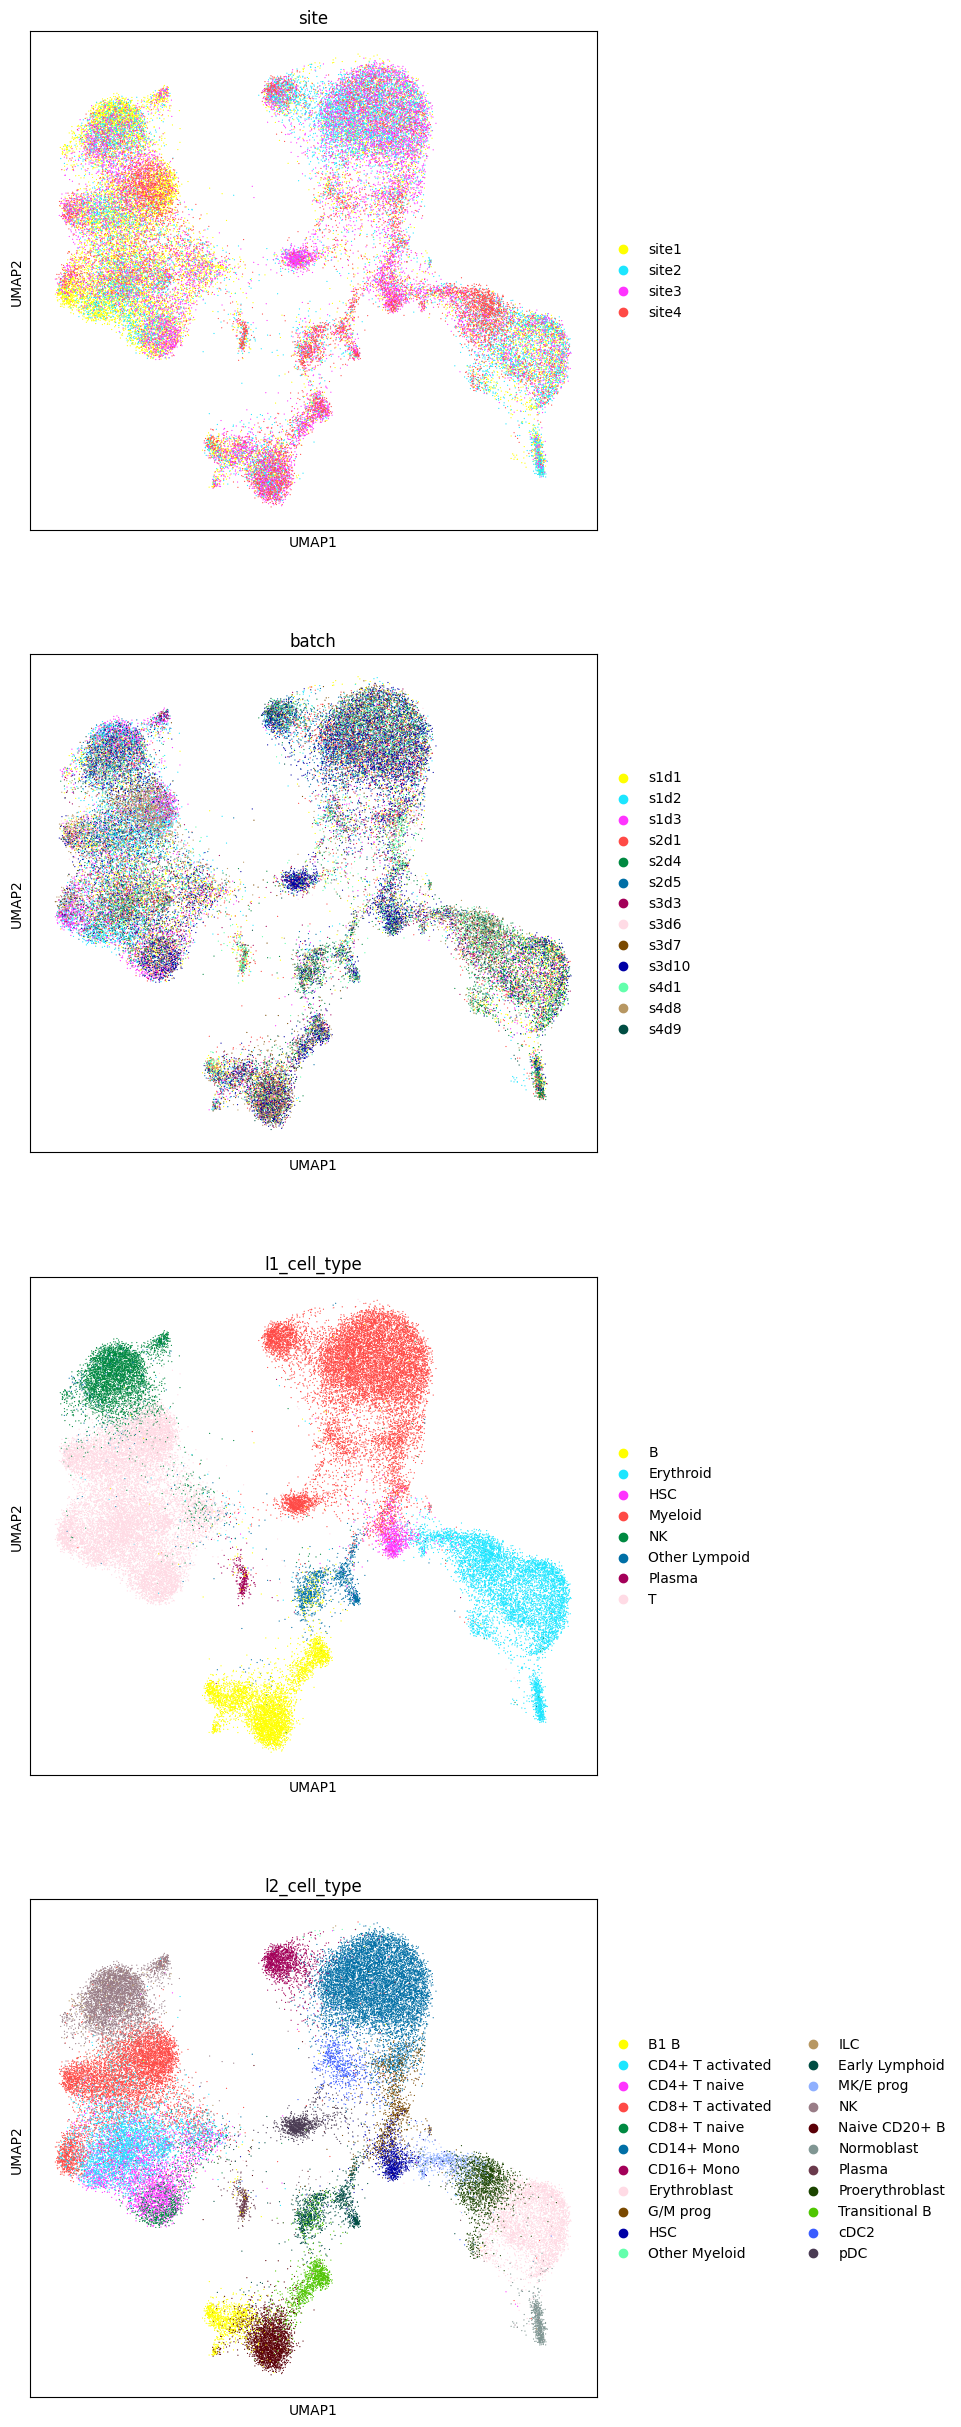

In [17]:
# UMAP coloured by batch, site, and cell type annotations
color = ["site", "batch", "l1_cell_type", "l2_cell_type"]

rcParams["figure.figsize"] = 7, 7
sc.pl.umap(
    adata,
    color=color,
    color_map="RdPu",
    ncols=1,
    palette=sc.pl.palettes.default_102 + sc.pl.palettes.zeileis_28 + sc.pl.palettes.vega_20_scanpy,
    size=3,
    vmin=0,
    vmax="p99.9",
    gene_symbols="SYMBOL",
    use_raw=False,
    legend_fontsize=10,
)

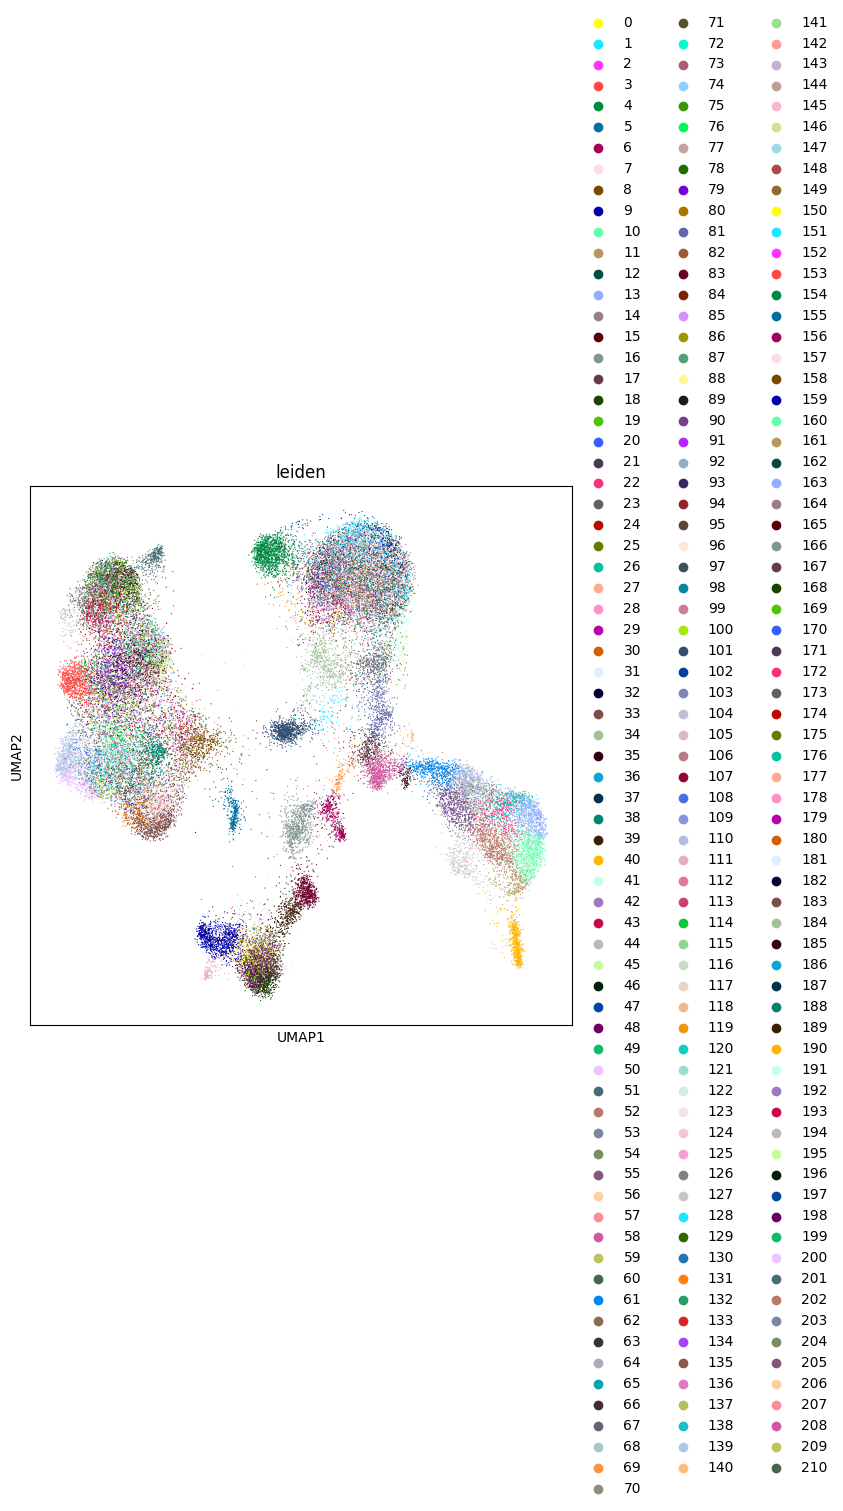

In [18]:
# Leiden clusters
rcParams["figure.figsize"] = 7, 7
sc.pl.umap(
    adata,
    color="leiden",
    color_map="RdPu",
    ncols=1,
    palette=sc.pl.palettes.default_102 + sc.pl.palettes.zeileis_28 + sc.pl.palettes.vega_20_scanpy,
    size=3,
    legend_fontsize=10,
)

## 6. Marker gene visualisation

Normalise marker genes per cell (counts per 10k) and overlay on UMAP to verify that the latent space captures expected biology.

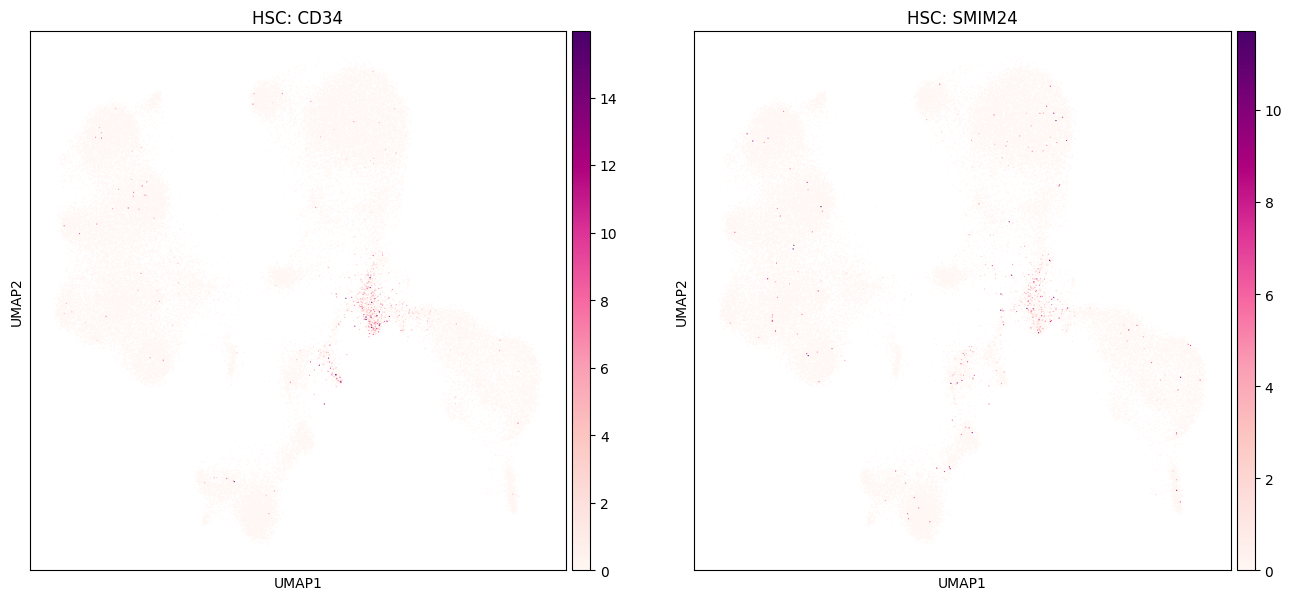

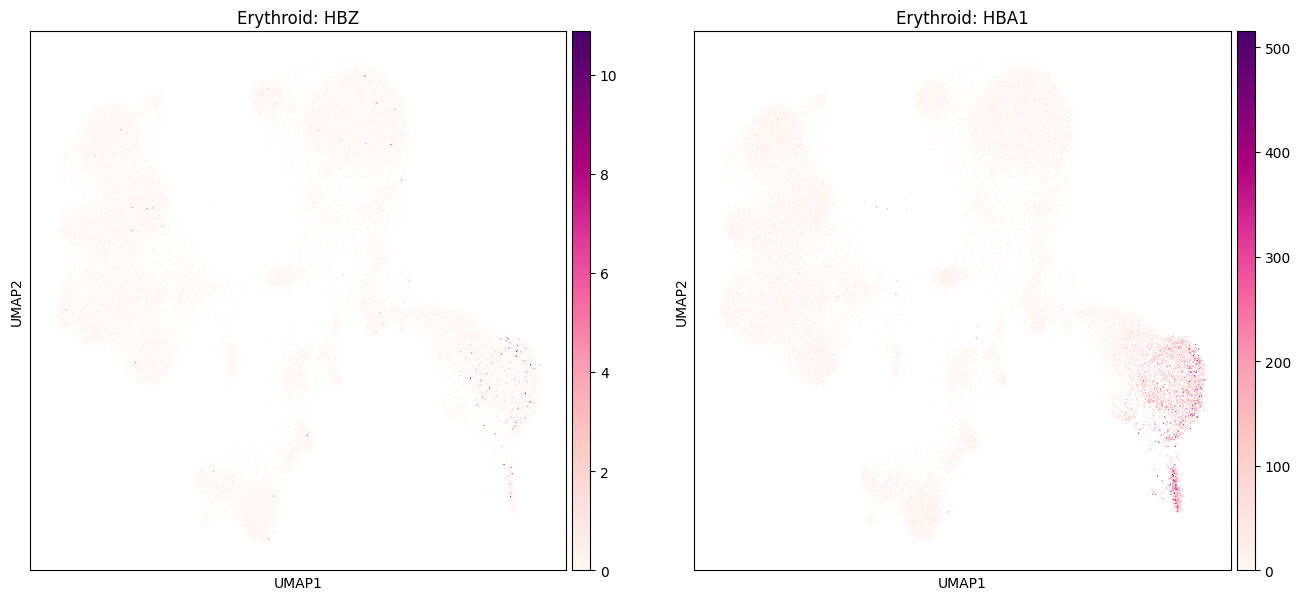

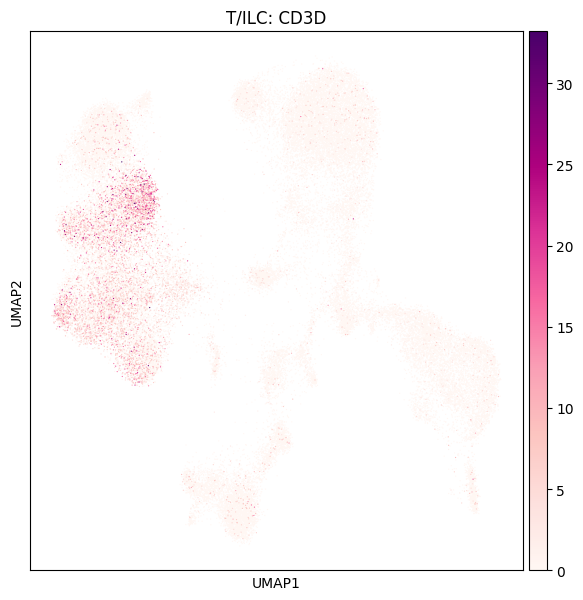

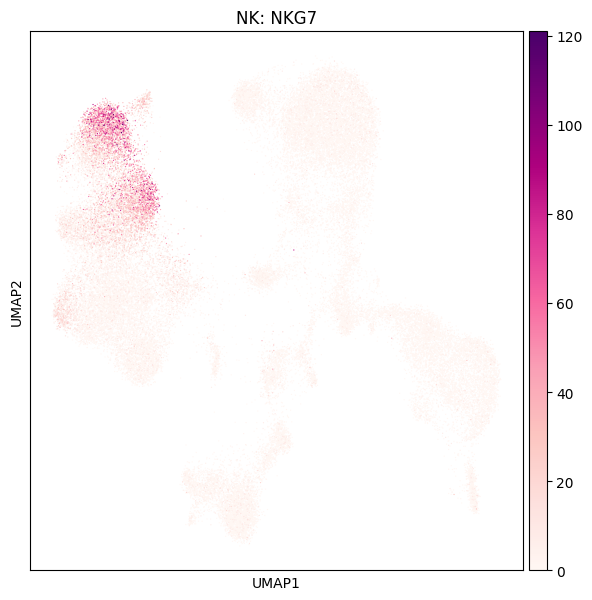

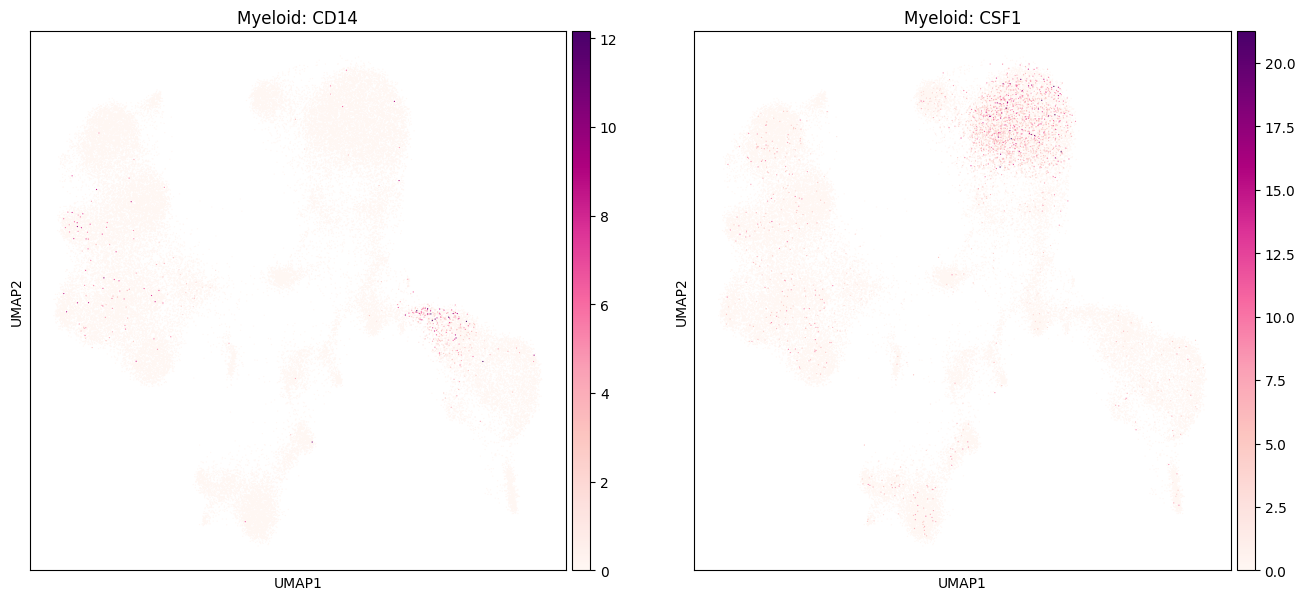

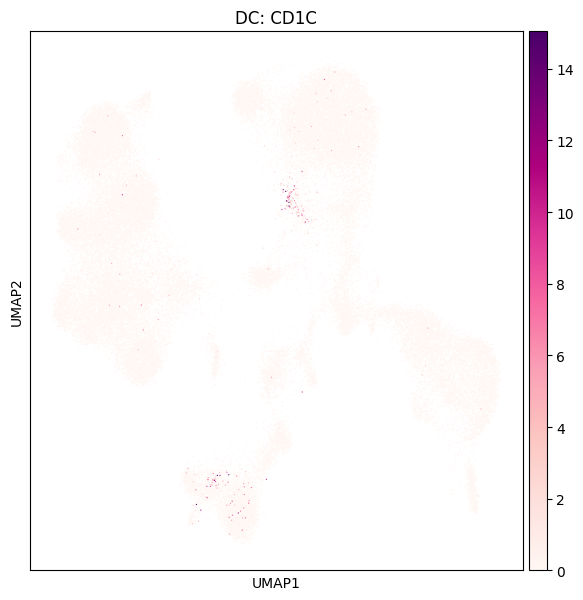

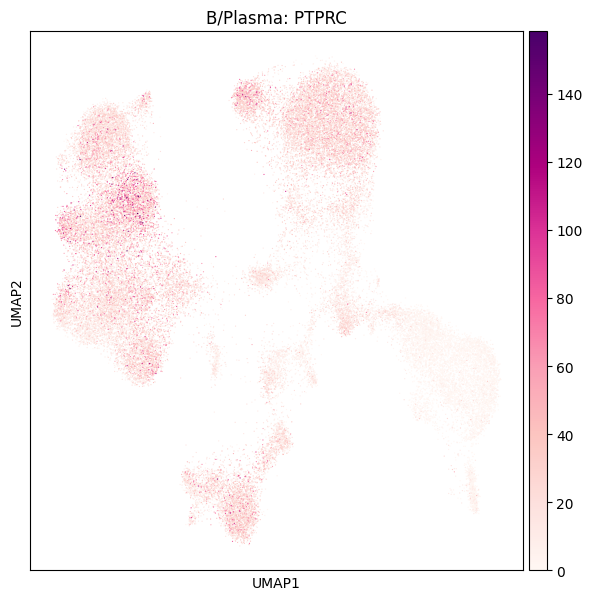

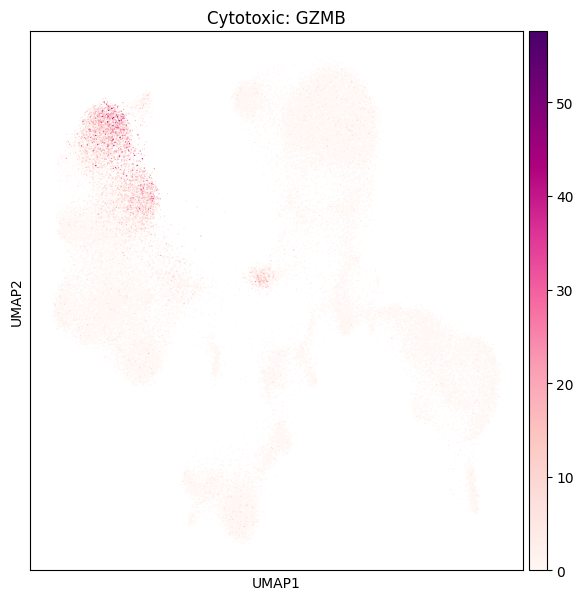

In [19]:
markers = {
    "HSC": ["CD34", "SMIM24"],
    "Erythroid": ["HBZ", "HBA1"],
    "T/ILC": ["CD3D"],
    "NK": ["NKG7"],
    "Myeloid": ["CD14", "CSF1"],
    "DC": ["CD1C"],
    "B/Plasma": ["PTPRC"],
    "Cytotoxic": ["GZMB"],
}

for group_name, gene_list in markers.items():
    # Filter to genes present in the data
    present = [g for g in gene_list if g in adata.var["SYMBOL"].values]
    if not present:
        continue

    # Normalise: counts per 10k
    gene_idx = adata.var["SYMBOL"].isin(present)
    selected_expr = adata[:, gene_idx].X.multiply(1.0 / adata.obs[["GEX_n_counts"]].values)
    selected_expr = selected_expr.toarray() * 1e4

    col_names = [f"{m} normalised" for m in present]
    adata.obs[col_names] = selected_expr

    sc.pl.umap(
        adata,
        color=col_names,
        color_map="RdPu",
        ncols=len(col_names),
        size=3,
        vmin=0,
        vmax="p99.99",
        gene_symbols="SYMBOL",
        use_raw=False,
        legend_fontsize=10,
        title=[f"{group_name}: {m}" for m in present],
    )

## 7. Save outputs

In [20]:
output_dir = f"{ref_run_name}/outputs/"
os.makedirs(output_dir, exist_ok=True)

# Save latent representation
X_scVI = pd.DataFrame(
    adata.obsm["X_scVI"],
    index=adata.obs_names,
    columns=range(adata.obsm["X_scVI"].shape[1]),
)
X_scVI.to_csv(f"{output_dir}/X_scVI.csv")

# Save UMAP coordinates
X_umap = pd.DataFrame(
    adata.obsm["X_umap"],
    index=adata.obs_names,
    columns=range(2),
)
X_umap.to_csv(f"{output_dir}/X_umap_k{k}.csv")

# Save leiden clustering
adata.obs[["leiden"]].to_csv(f"{output_dir}/leiden_k{k}.csv")

# Save KNN graph
scipy.sparse.save_npz(
    f"{output_dir}/distances_euclidean_k{k}.npz",
    adata.obsp["distances"],
    compressed=True,
)
scipy.sparse.save_npz(
    f"{output_dir}/connectivities_euclidean_k{k}.npz",
    adata.obsp["connectivities"],
    compressed=True,
)

print(f"Outputs saved to {output_dir}")

Outputs saved to results/regularizedvi_gamma_poisson_early_stopping//model/outputs/


In [ ]:
finish_wandb()

## Summary

This notebook used `AmbientRegularizedSCVI` with the default GammaPoisson likelihood and early stopping (`patience=20`, monitoring `elbo_validation`). Checkpoints saved every 200 epochs. Compare with the fixed-epoch variants to determine optimal training duration.